In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from arch import arch_model
from pathlib import Path

Path("../figures").mkdir(exist_ok=True)

# load main regression dataset and the raw CEE returns
df = pd.read_parquet("../data/regression_data.parquet")
cee_returns = pd.read_parquet("../data/cee_returns.parquet")

print(f"Regression data:  {df.shape}")
print(f"CEE returns:      {cee_returns.shape}")
print(f"Date range: {df.index[0].date()} to {df.index[-1].date()}")
df.head()

Regression data:  (1635, 6)
CEE returns:      (1636, 4)
Date range: 2018-01-04 to 2024-12-23


,VIX_level,VIX_change,WIG20_next,BUX_next,PX_next,ATX_next
Date,,,,,,
2018-01-04,9.22,0.070001,-0.001430,0.003636,0.000172,0.000124
2018-01-05,9.22,0.000000,0.007507,0.002718,0.003252,-0.000183
2018-01-08,9.52,0.300000,-0.007969,-0.005864,-0.004012,0.002336
2018-01-09,10.08,0.559999,-0.006790,-0.005491,-0.002493,0.009308
2018-01-10,9.82,-0.260000,0.009231,0.003060,0.005386,0.002765


In [3]:
# fit GARCH(1,1) to each CEE return series
# the arch package expects returns in percent, not decimal — multiply by 100
markets = ["WIG20", "BUX", "PX", "ATX"]
garch_results = {}

print("Fitting GARCH(1,1) for each CEE market...\n")
for mkt in markets:
    returns_pct = cee_returns[mkt].dropna() * 100
    
    # GARCH(1,1) with constant mean
    am = arch_model(returns_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="normal")
    res = am.fit(disp="off")
    garch_results[mkt] = res
    
    # print parameters
    print(f"{mkt}:")
    print(f"  omega = {res.params['omega']:.5f}")
    print(f"  alpha = {res.params['alpha[1]']:.5f}")
    print(f"  beta  = {res.params['beta[1]']:.5f}")
    print(f"  persistence (alpha + beta) = {res.params['alpha[1]'] + res.params['beta[1]']:.4f}")
    print(f"  log-likelihood = {res.loglikelihood:.1f}\n")

Fitting GARCH(1,1) for each CEE market...

WIG20:
  omega = 0.09036
  alpha = 0.08744
  beta  = 0.87051
  persistence (alpha + beta) = 0.9579
  log-likelihood = -2850.0

BUX:
  omega = 0.06977
  alpha = 0.12472
  beta  = 0.82964
  persistence (alpha + beta) = 0.9544
  log-likelihood = -2511.0

PX:
  omega = 0.03341
  alpha = 0.14469
  beta  = 0.81693
  persistence (alpha + beta) = 0.9616
  log-likelihood = -1957.9

ATX:
  omega = 0.07287
  alpha = 0.16974
  beta  = 0.79481
  persistence (alpha + beta) = 0.9646
  log-likelihood = -2546.4



In [4]:
# extract conditional volatility (standard deviation, not variance)
# and standardize next-day returns by their conditional volatility
standardized_returns = pd.DataFrame(index=cee_returns.index)

for mkt in markets:
    # conditional volatility from the GARCH fit (in percent, since we fitted on percent returns)
    cond_vol_pct = garch_results[mkt].conditional_volatility
    
    # convert back to decimal scale to match raw returns
    cond_vol = cond_vol_pct / 100
    
    # store
    standardized_returns[f"{mkt}_cond_vol"] = cond_vol
    standardized_returns[f"{mkt}_standardized"] = cee_returns[mkt] / cond_vol

# preview
print("Conditional volatility and standardized return summary:\n")
for mkt in markets:
    cv = standardized_returns[f"{mkt}_cond_vol"]
    sr = standardized_returns[f"{mkt}_standardized"].dropna()
    print(f"{mkt}:")
    print(f"  Conditional vol — mean: {cv.mean()*100:.3f}%, min: {cv.min()*100:.3f}%, max: {cv.max()*100:.3f}%")
    print(f"  Standardized return — mean: {sr.mean():.4f}, std: {sr.std():.4f}, min: {sr.min():.3f}, max: {sr.max():.3f}\n")

Conditional volatility and standardized return summary:

WIG20:
  Conditional vol — mean: 1.426%, min: 0.936%, max: 5.324%
  Standardized return — mean: -0.0180, std: 1.0000, min: -6.613, max: 3.808

BUX:
  Conditional vol — mean: 1.193%, min: 0.723%, max: 5.643%
  Standardized return — mean: 0.0456, std: 0.9991, min: -5.710, max: 3.770

PX:
  Conditional vol — mean: 0.864%, min: 0.488%, max: 4.577%
  Standardized return — mean: 0.0399, std: 0.9998, min: -4.724, max: 5.065

ATX:
  Conditional vol — mean: 1.248%, min: 0.683%, max: 7.106%
  Standardized return — mean: 0.0043, std: 0.9989, min: -5.217, max: 5.052



In [5]:
# build regression dataset using standardized next-day returns
# we keep VIX_level and VIX_change as-is, but replace the dependent variable
# with the volatility-standardized version

garch_df = pd.DataFrame({
    "VIX_level"  : df["VIX_level"],
    "VIX_change" : df["VIX_change"],
}, index=df.index)

# add standardized next-day returns (shift to align with VIX info)
for mkt in markets:
    sr = standardized_returns[f"{mkt}_standardized"]
    garch_df[f"{mkt}_next_std"] = sr.shift(-1)

garch_df = garch_df.dropna()

print(f"GARCH regression dataset: {garch_df.shape}")
print(f"Date range: {garch_df.index[0].date()} to {garch_df.index[-1].date()}")
garch_df.head()

GARCH regression dataset: (1635, 6)
Date range: 2018-01-04 to 2024-12-23


,VIX_level,VIX_change,WIG20_next_std,BUX_next_std,PX_next_std,ATX_next_std
Date,,,,,,
2018-01-04,9.22,0.070001,-0.100152,0.370134,0.019281,0.009713
2018-01-05,9.22,0.000000,0.549307,0.289751,0.393434,-0.015657
2018-01-08,9.52,0.300000,-0.600228,-0.653775,-0.517253,0.217023
2018-01-09,10.08,0.559999,-0.523379,-0.616587,-0.334431,0.931113
2018-01-10,9.82,-0.260000,0.730217,0.346996,0.760780,0.276906


In [6]:
from statsmodels.iolib.summary2 import summary_col

def run_ols(y, X, lags=5):
    X_with_const = sm.add_constant(X)
    return sm.OLS(y, X_with_const).fit(cov_type="HAC", cov_kwds={"maxlags": lags})

# run regression on standardized returns for each market
garch_results_ols = {}
X = garch_df[["VIX_level", "VIX_change"]]

for mkt in markets:
    y = garch_df[f"{mkt}_next_std"]
    garch_results_ols[mkt] = run_ols(y, X)

# build comparison table
summary = summary_col(
    list(garch_results_ols.values()),
    model_names=markets,
    stars=True,
    info_dict={
        "N"  : lambda x: f"{int(x.nobs)}",
        "R²" : lambda x: f"{x.rsquared:.4f}",
    },
    regressor_order=["const", "VIX_level", "VIX_change"]
)

print("Table 7: Baseline Regression on GARCH(1,1)-Standardized Returns")
print("Dependent variable: standardized next-day log return")
print("Newey-West HAC standard errors with 5 lags\n")
print(summary)

Table 7: Baseline Regression on GARCH(1,1)-Standardized Returns
Dependent variable: standardized next-day log return
Newey-West HAC standard errors with 5 lags


                 WIG20       BUX         PX        ATX    
----------------------------------------------------------
const          -0.0203    0.1229**   0.1278*    0.0269    
               (0.0641)   (0.0610)   (0.0674)   (0.0699)  
VIX_level      0.0001     -0.0039    -0.0045    -0.0012   
               (0.0032)   (0.0030)   (0.0033)   (0.0035)  
VIX_change     -0.0670*** -0.0687*** -0.0768*** -0.0690***
               (0.0228)   (0.0208)   (0.0226)   (0.0192)  
R-squared      0.0207     0.0239     0.0300     0.0225    
R-squared Adj. 0.0195     0.0227     0.0289     0.0213    
N              1635       1635       1635       1635      
R²             0.0207     0.0239     0.0300     0.0225    
Standard errors in parentheses.
* p<.1, ** p<.05, ***p<.01


In [8]:
# load baseline results to compare
baseline_results = {}
X_baseline = df[["VIX_level", "VIX_change"]]
for mkt in markets:
    y = df[f"{mkt}_next"]
    baseline_results[mkt] = run_ols(y, X_baseline)

# build the comparison table: baseline vs GARCH-standardized
def stars(pval):
    if pval < 0.01: return "***"
    elif pval < 0.05: return "**"
    elif pval < 0.10: return "*"
    else: return ""

rows = []
for mkt in markets:
    b = baseline_results[mkt]
    g = garch_results_ols[mkt]
    rows.append({
        "Market"      : mkt,
        "Baseline β₂" : f"{b.params['VIX_change']:.5f}{stars(b.pvalues['VIX_change'])}",
        "Baseline SE" : f"({b.bse['VIX_change']:.5f})",
        "Baseline R²" : f"{b.rsquared:.4f}",
        "GARCH β₂"    : f"{g.params['VIX_change']:.5f}{stars(g.pvalues['VIX_change'])}",
        "GARCH SE"    : f"({g.bse['VIX_change']:.5f})",
        "GARCH R²"    : f"{g.rsquared:.4f}",
    })

comparison = pd.DataFrame(rows).set_index("Market")
print("Table 7: Baseline OLS vs GARCH(1,1)-Standardized OLS\n")
print(comparison.to_string())

comparison.to_csv("../data/table_7_garch_robustness.csv")
print("\nSaved → data/table_7_garch_robustness.csv")
print("\nNote: *, **, *** denote significance at 10%, 5%, 1%.")
print("Newey-West HAC standard errors with 5 lags.")

Table 7: Baseline OLS vs GARCH(1,1)-Standardized OLS

       Baseline β₂ Baseline SE Baseline R²     GARCH β₂   GARCH SE GARCH R²
Market                                                                     
WIG20     -0.00080   (0.00050)      0.0127  -0.06702***  (0.02281)   0.0207
BUX      -0.00076*   (0.00042)      0.0176  -0.06872***  (0.02076)   0.0239
PX      -0.00065**   (0.00033)      0.0250  -0.07680***  (0.02258)   0.0300
ATX      -0.00079*   (0.00041)      0.0155  -0.06897***  (0.01921)   0.0225

Saved → data/table_7_garch_robustness.csv

Note: *, **, *** denote significance at 10%, 5%, 1%.
Newey-West HAC standard errors with 5 lags.


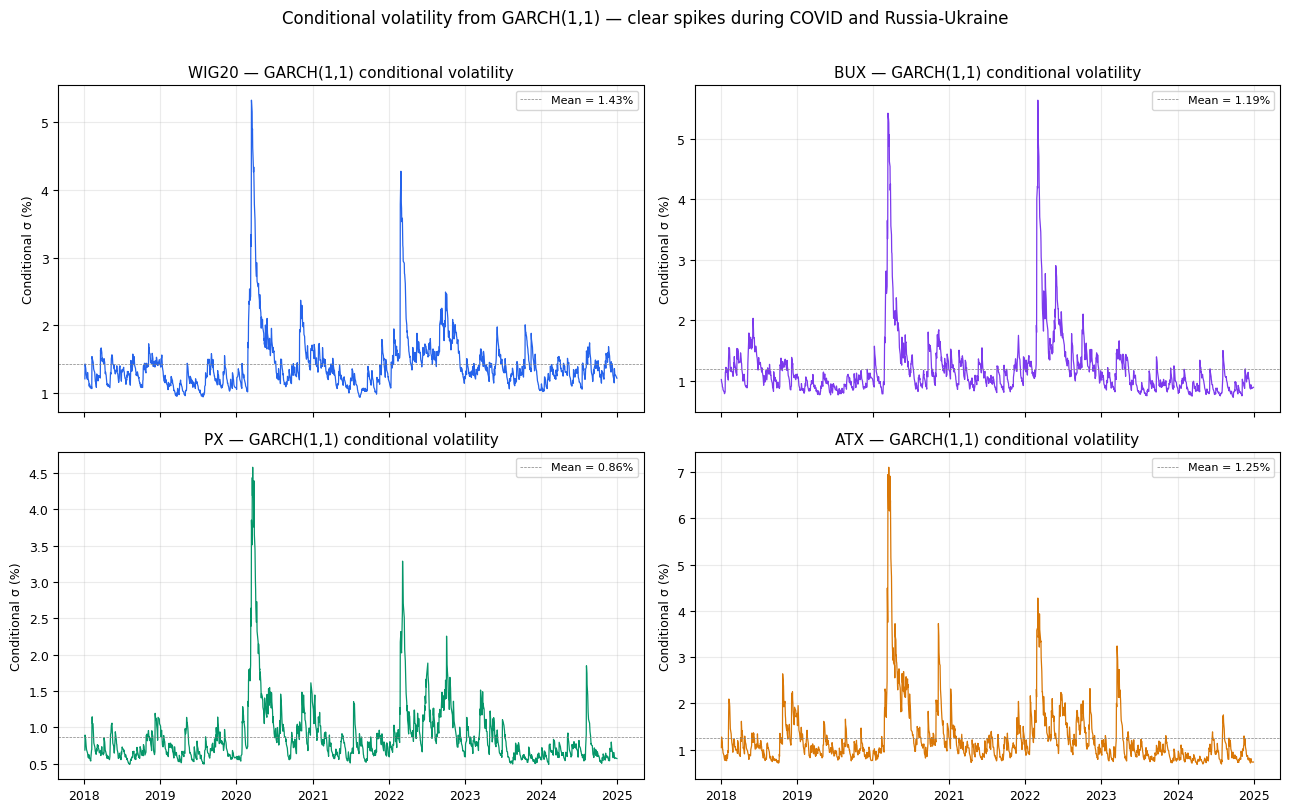

Saved → figures/07_garch_volatility.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
axes = axes.flatten()

colors = {"WIG20": "#2563eb", "BUX": "#7c3aed",
          "PX": "#059669", "ATX": "#d97706"}

for i, mkt in enumerate(markets):
    cv = standardized_returns[f"{mkt}_cond_vol"] * 100  # in percent
    axes[i].plot(cv.index, cv, color=colors[mkt], linewidth=0.9)
    axes[i].set_title(f"{mkt} — GARCH(1,1) conditional volatility",
                      fontsize=11, fontweight="500")
    axes[i].set_ylabel("Conditional σ (%)", fontsize=9)
    axes[i].tick_params(labelsize=9)
    axes[i].grid(alpha=0.25)
    axes[i].axhline(cv.mean(), color="gray", linewidth=0.5,
                    linestyle="--", label=f"Mean = {cv.mean():.2f}%")
    axes[i].legend(fontsize=8, loc="upper right")

fig.suptitle("Conditional volatility from GARCH(1,1) — clear spikes during COVID and Russia-Ukraine",
             fontsize=12, fontweight="500", y=1.01)
plt.tight_layout()
plt.savefig("../figures/07_garch_volatility.png", dpi=150, bbox_inches="tight")
plt.show()